# ATLIQO BANK CREDIT CARD LAUNCH - PHASE 1: FIND TARGET MARKET

Imagine post-COVID era where banks suffer due to reduction in revenue triggered by less spending by customers owing to the epidemic which sees victims emerge every other day.
*Atliqo Bank* decides to launch a new credit card in the market amidst other popular market players such as HDFC, SBI etc. 

To ensure that the credit card launch reaches the right set of customers so that it improves revenue you as a Data Scientist need to figure out the target audience given transaction data obtained from a third-party website named *Data Lelo*.

In [2]:
# import the necessary packages
import os
import pandas as pd
import numpy as np
import seaborn as sns
import mysql.connector
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [3]:
os.listdir()

['Analysis_imgs',
 'Atliqo_bank_credit_card_find_target_market.ipynb',
 'AB_Test_For_New_Credit_Card.ipynb']

In [4]:
os.getcwd()

'/Users/soumyadipsikdar/Desktop/Data Science/Data_Analysis/Atliqo_Credit_Card'

Observations: 
1. *Customer_df* : Contains information regarding customers to be targeted sucg as their **annual income**, whether married or single, name etc. This gives an idea of which all customers are more inclined towards purchase of new credit cards. 

2. *Transactions_df* : Highlights different transactions made by customers which gives insight as to where do they buy most from. For instance purchase from e-commerce sites provides more opportunity to sell credit cards since such sites usually offer higher discounts when purchasing via *Credit Cards*. 

3. *credit_profiles_df* : Helps understand *credit default risk* which exposes banks to large losses.

## FETCH DATA FROM DATABASE AND RUN SQL QUERIES
Here we fetch data not from *CSV* but from *MYSQL* database instead. Then we execute *SQL* queries to extract relevant data from respective tables in database.

In [5]:
# fetch necessary db login credentials from .env file
load_dotenv()

True

In [6]:
# setup database connection
mysql_conn = mysql.connector.connect(
    host=os.getenv('DB_HOST'),
    user=os.getenv('DB_USER'),
    password=os.getenv('MYSQL_password'),
    database=os.getenv('DB_NAME')
)

if mysql_conn.is_connected():
    print('Database connection successful.')
else:
    print("Database connection failed")

Database connection successful.


In [7]:
# run SQL queries to fetch data from database and store them in respective dataframes.
customer_df = pd.read_sql("select * from customers;",mysql_conn)
transactions_df = pd.read_sql("select * from transactions;",mysql_conn)
credit_profiles_df = pd.read_sql("select * from credit_profiles;",mysql_conn)

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/4149308609.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_df = pd.read_sql("select * from customers;",mysql_conn)
/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/4149308609.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_df = pd.read_sql("select * from transactions;",mysql_conn)
/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/4149308609.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  credit_p

#### DISPLAY FIRST FEW ROWS OF RESPECTIVE DATAFRAMES

In [8]:
customer_df.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [9]:
transactions_df.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [10]:
credit_profiles_df.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


### PERFORM EDA 
Here we perform *Exploratory Data Analysis* on the above dataframes obtained.

In [11]:
customer_df.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


Observations, 
1. From above we find that there is certainly some issue with the data since *Age* range is absurd spanning *1 yrs - 135 yrs*. 
2. In the *Annual Income* section a minimumu of just *2$* is not possible and is absurd as well. 

Hence the above issues are rectified below.

In [12]:
# check for null values.
customer_df.isna().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

Observations, 
1. There exists **50** null values under *annual income* attribute. We fill those values using either *Mean/Median* depending on how the distribution of annual income is.

In [13]:
# replace null with occupation-wise median value.
mediansal_occupationwise_df = customer_df.groupby(['occupation'])['annual_income'].agg("median")
mediansal_occupationwise_df.head()

occupation
Accountant         65265.0
Artist             45794.0
Business Owner    261191.5
Consultant         58017.0
Data Scientist    135759.0
Name: annual_income, dtype: float64

In [14]:
mediansal_occupationwise_df.index

Index(['Accountant', 'Artist', 'Business Owner', 'Consultant',
       'Data Scientist', 'Freelancer', 'Fullstack Developer'],
      dtype='object', name='occupation')

In [15]:
# fill missing values with respective median values as per occupation

customer_df.loc[customer_df['annual_income'].isna(),'annual_income'] = customer_df.loc[customer_df['annual_income'].isna(),'occupation'].map(mediansal_occupationwise_df)

In [16]:
# check for presence of null values.
customer_df.isna().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [17]:
# sanity check to see whether values are aligned as per occupation
customer_df.loc[[14,82]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single


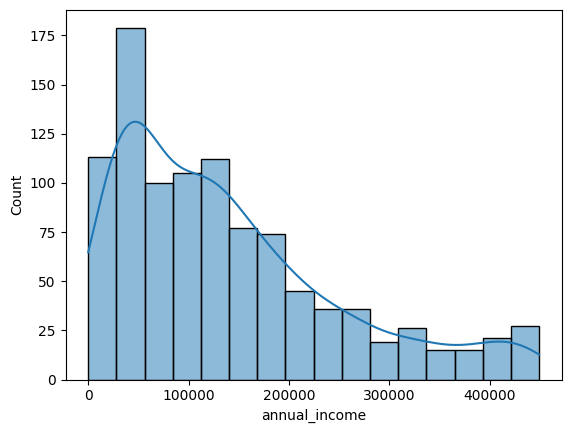

In [18]:
# plot histogram of annual income
sns.histplot(data=customer_df,x='annual_income',kde=True)
plt.show()

Observations, 
1. Above pdf clearly is *right-skewed* meaning there exists outliers indicated by entries on the far right which extends the tail. Hence we use *Median* instead of *Mean* to replace missing values since the former is more robust to outliers. 

#### HANDLE OUTLIERS
Next we treat **outliers** in the *annual income* column. We can adopt 3 processes for this, 
1. Standard Deviation 
2. Box and whisker plot 
3. Ask business manager for a threshold. 

We consider the last approach here using **threshold** as 100$.

In [19]:
# use box-whisker plot to get the lower and upper limit within which most values lie. Any value outside this range is to be treated as an outlier.
threshold = 100

customer_df['annual_income'] = np.where(customer_df['annual_income']<threshold,mediansal_occupationwise_df[customer_df['occupation']],customer_df['annual_income'])

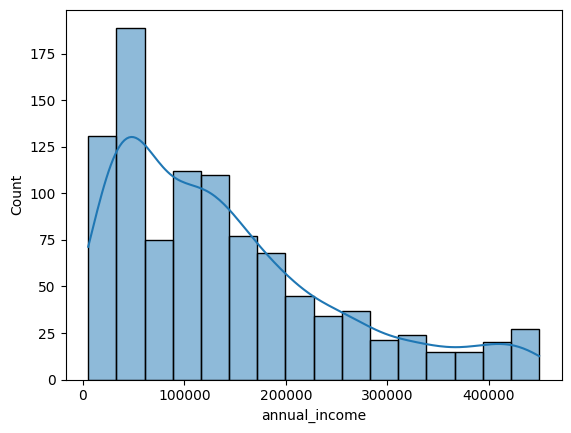

In [20]:
# plot to check whether outliers have been replaced or not
sns.histplot(data=customer_df,x='annual_income',kde=True)
plt.show()

In [21]:
customer_df.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,140483.548500
std,288.819436,15.666155,110463.002934
min,1.000000,1.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,46.000000,195514.250000
max,1000.000000,135.000000,449346.000000


#### VISUALIZE OCCUPATION-WISE, AGE-WISE, MARITAL-STATUS WISE, GENDERWISE AND LOCATION WISE MEAN SALARY

In [22]:
occupationwise_mean_salary = customer_df.groupby(['occupation'])['annual_income'].agg("mean")
occupationwise_mean_salary = occupationwise_mean_salary.sort_values()
occupationwise_mean_salary

occupation
Artist                  45309.236842
Consultant              60703.154639
Accountant              64123.562500
Freelancer              76327.508772
Fullstack Developer     78727.972973
Data Scientist         137021.266304
Business Owner         268447.368512
Name: annual_income, dtype: float64

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/457678240.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(occupationwise_mean_salary,palette='tab10')


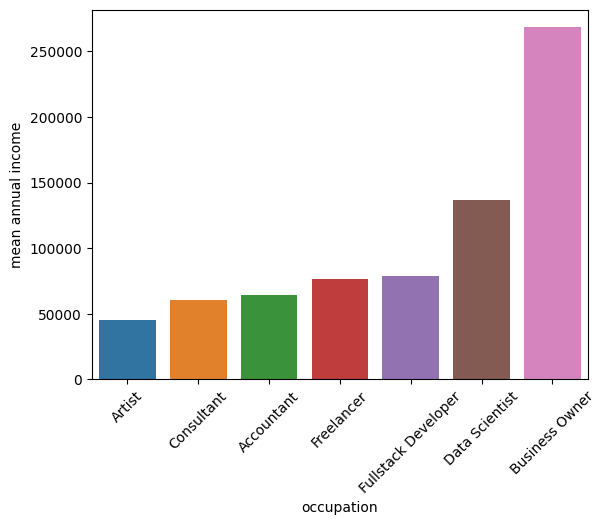

In [23]:
sns.barplot(occupationwise_mean_salary,palette='tab10')
plt.ylabel('mean annual income')
plt.xticks(rotation=45)
plt.show()

In [24]:
maritalstatuswise_mean_salary = customer_df.groupby(['marital_status'])['annual_income'].agg("mean").sort_values()
genderwise_mean_salary = customer_df.groupby(['gender'])['annual_income'].agg("mean").sort_values()
agewise_mean_salary = customer_df.groupby(['age'])['annual_income'].agg("mean").sort_values()
locationwise_mean_salary = customer_df.groupby(['location'])['annual_income'].agg("mean").sort_values()

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/1810393522.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(locationwise_mean_salary,ax=axes[0,0],palette='tab10')
/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/1810393522.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(maritalstatuswise_mean_salary,ax=axes[0,1],palette='tab10')
/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/1810393522.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(genderwise_mean_salary,ax=axes[1,0],palette='ta

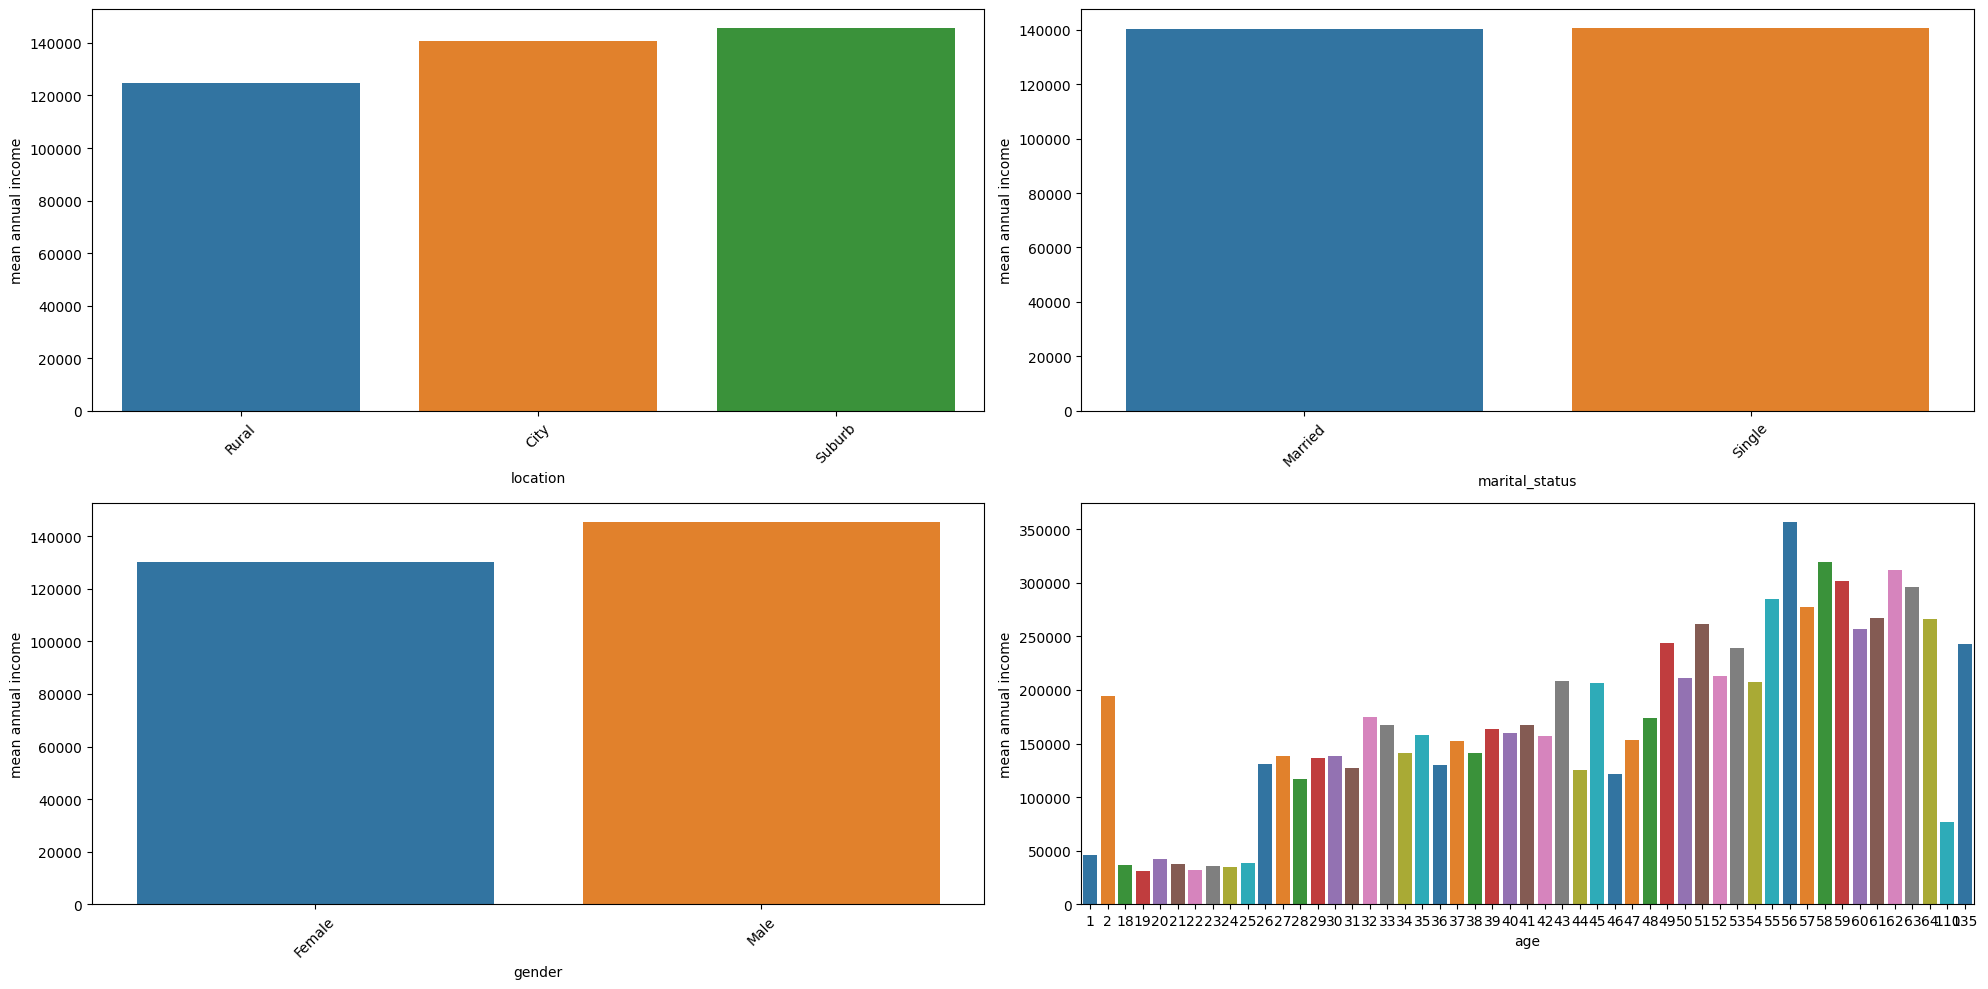

In [25]:
fig,axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(20,10)

sns.barplot(locationwise_mean_salary,ax=axes[0,0],palette='tab10')
axes[0,0].set_ylabel('mean annual income')
axes[0,0].tick_params(axis='x',rotation=45)

sns.barplot(maritalstatuswise_mean_salary,ax=axes[0,1],palette='tab10')
axes[0,1].set_ylabel('mean annual income')
axes[0,1].tick_params(axis='x',rotation=45)

sns.barplot(genderwise_mean_salary,ax=axes[1,0],palette='tab10')
axes[1,0].set_ylabel('mean annual income')
axes[1,0].tick_params(axis='x',rotation=45)

sns.barplot(agewise_mean_salary,ax=axes[1,1],palette='tab10')
axes[1,1].set_ylabel('mean annual income')

plt.tight_layout()
plt.show()

Next we handle **outliers** under *Age* attribute such that we keep only values between **15 yrs to 80 yrs**.

In [26]:
print(f"Min age: {customer_df['age'].min()}, Max age: {customer_df['age'].max()}")

Min age: 1, Max age: 135


In [27]:
# find number of outliers basis above threshold
age_outliers = customer_df.loc[(customer_df['age']<15) | (customer_df['age']>80)]
print(f'% of outliers basis age is: {(len(age_outliers)/len(customer_df))*100}%')

% of outliers basis age is: 2.0%


Observations, 
1. Since the number of outliers basis *Age threshold* is small we can either remove them entirely or replace them with it's mean/median value. 

Here we replace them with the *Median* value occupation-wise.

In [28]:
occupationwise_age = customer_df.groupby(['occupation'])['age'].agg("median")
occupationwise_age = occupationwise_age.sort_values()
occupationwise_age

occupation
Freelancer             24.0
Artist                 26.0
Fullstack Developer    27.5
Accountant             31.5
Data Scientist         32.0
Consultant             46.0
Business Owner         51.0
Name: age, dtype: float64

In [29]:
customer_df['age'] = np.where((customer_df['age']<15) | (customer_df['age']>80),occupationwise_age[customer_df['occupation']],customer_df['age'])

In [30]:
# sanity check to ensure outliers no longer exist.
print(f"Min age: {customer_df['age'].min()}, Max age: {customer_df['age'].max()}")

Min age: 18.0, Max age: 64.0


#### VISUALISE CUSTOMER COUNT BASIS AGE GROUPS
Here we create a pie-chart indicating customer count basis age-groups.

In [31]:
# we setup custom age groups like 18-25 -> Young adult, 26-35 -> young adult, 36-48 -> adult, 49-65 -> Middle aged
bins = [18, 25, 35, 48, 65]
labels = ['18-25', '26-35', '36-48', '49+']

customer_df['age_groups'] = pd.cut(customer_df['age'],bins=bins, labels=labels, right=True)

In [32]:
customer_df.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_groups
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,36-48
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,36-48


In [33]:
# plot pie-chart basis customer count per age-group
customer_count_agegroupwise = customer_df.groupby(['age_groups'])['cust_id'].agg("count").sort_values()
customer_count_agegroupwise

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/3057600977.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_count_agegroupwise = customer_df.groupby(['age_groups'])['cust_id'].agg("count").sort_values()


age_groups
49+      187
36-48    220
18-25    231
26-35    347
Name: cust_id, dtype: int64

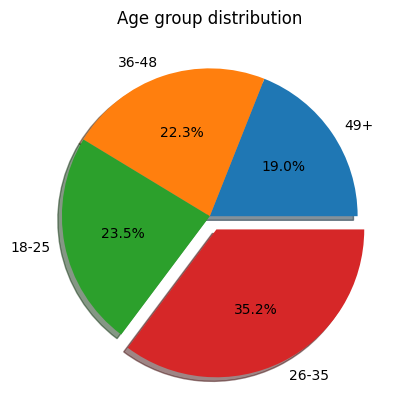

In [34]:
# plot distribution
plt.pie(x=customer_count_agegroupwise.values,labels=customer_count_agegroupwise.index,autopct='%1.1f%%',shadow=True, explode=(0,0,0,0.1))
plt.title("Age group distribution")
plt.show()

#### VISUALIZE CUSTOMER COUNT BASIS GENDER PER LOCATION

In [35]:
location_and_genderwise_customer_counts = customer_df.groupby(['location','gender'])['cust_id'].agg("count").unstack()
location_and_genderwise_customer_counts

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


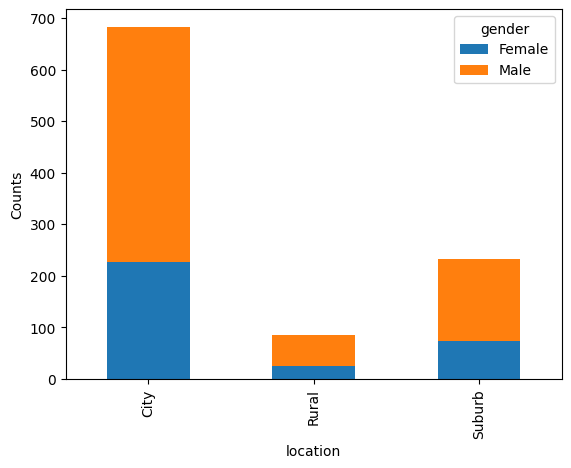

In [36]:
# plot location and gender-wise customer count in a stacked bar chart
location_and_genderwise_customer_counts.plot(kind='bar',stacked=True)
plt.ylabel('Counts')
plt.show()

### EDA ON CREDIT PROFILE
Below we perform **EDA** on *Credit profile* of customers.

In [37]:
credit_profiles_df.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [38]:
credit_profiles_df.shape

(1004, 6)

In [39]:
credit_profiles_df['cust_id'].nunique()

1000

In [40]:
credit_profiles_df.duplicated(subset=['cust_id']).sum()

np.int64(4)

Observations, 
1. The *credit profile* dataframe holds credit related info per customer. From above we find that the number of entries in it exceeds the no of customers present which is **1000** that suggests there are duplicates. 

Above displays presence of 4 duplicated entries in the dataframe.

In [41]:
# obtain all duplicated entries
duplicated_df = credit_profiles_df.loc[credit_profiles_df['cust_id'].duplicated(keep=False)]
duplicated_df

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


Observations, 
1. From above we see that for each set of duplicates only the second instance has valid values corresponding to **credit_utilisation**,**outstanding_debt** & **credit_inquiries_last_6_months**. Hence, we keep only the last instance and omit all other instances.

In [42]:
# keep only the last instances of each set of duplicated entries while removing the rest from 'cust_id' column.
credit_profiles_df = credit_profiles_df.drop_duplicates(subset=['cust_id'],keep='last')

In [43]:
# sanity check for presence of duplicates
credit_profiles_df.duplicated().any()

np.False_

Above result indicates that we have omitted all the duplicates keeping only the first instance.

In [44]:
# check for missing values
credit_profiles_df.isna().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

Observations, 
1. Above indicates presence of **65** missing values under **credit_limit**. 



#### VISUALIZE RELATIONSHIP BETWEEN CREDIT SCORE AND LIMIT.

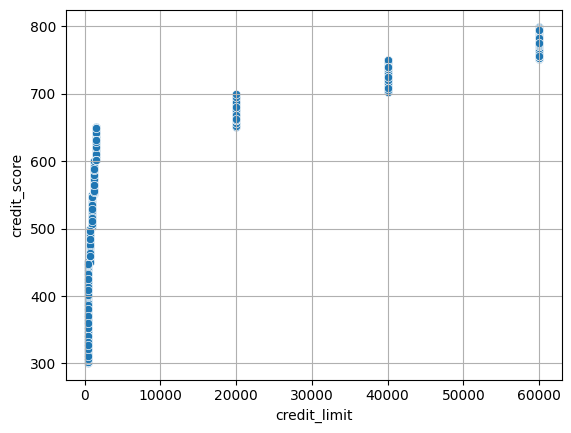

In [45]:
sns.scatterplot(data=credit_profiles_df,y='credit_score',x='credit_limit')
plt.grid(True)
plt.show()

Observations,
1. Above plot indicates that **credit limit** increases with increase in **credit score**. 
2. **credit score** is continuous and lies between **300-800**. 

Hence, we discretize the **credit score** into buckets and then basis the buckets in which missing **credit limits** fall in substitute the bucket-wise **Median** value of **credit limits**. 

To handle **NA** values thus we substitute missing values with **Mode** of **credit limit** corresponding to the **discretised credit score**.

In [46]:
print(f'Min credit-score: {credit_profiles_df.credit_score.min()}, Max credit-score: {credit_profiles_df.credit_score.max()}')

Min credit-score: 300, Max credit-score: 799


In [47]:
# discretize credit scores
bins = [300, 550, 650, 700, 750, np.inf]
labels = ['300-549','550-649','650-699','700-749','750+']

credit_profiles_df['credit_risk_band'] = pd.cut(credit_profiles_df['credit_score'],bins=bins,labels=labels, right=False)

In [48]:
# sanity check credit profiles dataframe
credit_profiles_df.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_risk_band
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,161644.0,2.0,1250.0,550-649
2,3,544,0.854807,513.0,4.0,1000.0,300-549
3,4,504,0.336938,224.0,2.0,1000.0,300-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


In [49]:
creditriskwise_creditlimit = credit_profiles_df.groupby(['credit_risk_band'])['credit_limit'].agg(lambda x: x.mode().iloc[0]).sort_values()
creditriskwise_creditlimit

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/1201198416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  creditriskwise_creditlimit = credit_profiles_df.groupby(['credit_risk_band'])['credit_limit'].agg(lambda x: x.mode().iloc[0]).sort_values()


credit_risk_band
300-549      500.0
550-649     1500.0
650-699    20000.0
700-749    40000.0
750+       60000.0
Name: credit_limit, dtype: float64

In [50]:
# impute missing values based on credit risk bands.
credit_profiles_df['credit_limit'] = np.where(credit_profiles_df['credit_limit'].isna(),creditriskwise_creditlimit[credit_profiles_df['credit_risk_band']],credit_profiles_df['credit_limit'])

In [51]:
# sanity check credit limit to see whether there exists missing values
credit_profiles_df.isna().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
credit_risk_band                  0
dtype: int64

In [52]:
credit_profiles_df.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19729.250000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24720.922433
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,500.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000


Observations, 
1. From above we find that with max **credit limit** set to **60000$** maximum **outstanding_debt** of **$209901** which is **~3.5** times is absurd.

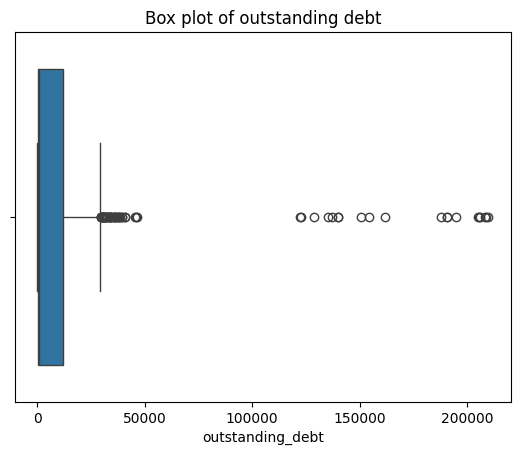

In [53]:
# plot box & whisker plot to visualize outliers
sns.boxplot(data=credit_profiles_df['outstanding_debt'],orient='h')
plt.title("Box plot of outstanding debt")
plt.show()

Observations, 
1. Removal of **Outliers** may be done using several methods such as **IQR, Std deviation etc.** or may even be carried out using **business knowledge**.

Here we use **Business knowledge** that says **Max outstanding debt cannot exceed credit limit**.

In [54]:
# filter out all entries with outstanding debt beyond credit limit.
outstanding_debt_outliers = credit_profiles_df.loc[credit_profiles_df['outstanding_debt']>credit_profiles_df['credit_limit']]

print(f'% of entries with outstanding debt outliers is: {(len(outstanding_debt_outliers)/len(credit_profiles_df))*100}%')

% of entries with outstanding debt outliers is: 2.0%


In [55]:
# replace outstanding debt outlier values with corresponding credit limits
credit_profiles_df['outstanding_debt'] = np.where(credit_profiles_df['outstanding_debt']>credit_profiles_df['credit_limit'],credit_profiles_df['credit_limit'],credit_profiles_df['outstanding_debt'])

In [56]:
# sanity check to see there exists no outliers under outstanding_debt
credit_profiles_df.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,6850.084000,1.955000,19729.250000
std,288.819436,152.284929,0.233139,10683.473561,1.414559,24720.922433
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,500.000000
50%,500.500000,601.500000,0.487422,541.500000,2.000000,1500.000000
75%,750.250000,738.000000,0.697829,10924.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,60000.000000,4.000000,60000.000000


### COMBINE CUSTOMERS INFORMATION WITH CUSTOMERS CREDIT PROFILE DATA
Below we merge customer's information with customer's credit profile data so we can obtain one data that displays entire record for every customer.

In [57]:
customer_df.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_groups
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,36-48
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,36-48


In [58]:
credit_profiles_df.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_risk_band
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,1250.0,2.0,1250.0,550-649
2,3,544,0.854807,513.0,4.0,1000.0,300-549
3,4,504,0.336938,224.0,2.0,1000.0,300-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


In [59]:
customer_df.shape,credit_profiles_df.shape

((1000, 9), (1000, 7))

In [60]:
customer_info_df = pd.merge(left=customer_df,right=credit_profiles_df,on='cust_id',how='inner')
customer_info_df.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_groups,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_risk_band
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,36-48,587,0.107928,1250.0,2.0,1250.0,550-649
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,300-549
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,300-549
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,36-48,708,0.586151,18090.0,2.0,40000.0,700-749


#### FIND CORRELATION AMONGST NUMERIC COLUMNS IN MERGED DATA
Below we find correlation between **numeric** columns in the merged dataframe above.

In [61]:
customer_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   cust_id                         1000 non-null   int64   
 1   name                            1000 non-null   object  
 2   gender                          1000 non-null   object  
 3   age                             1000 non-null   float64 
 4   location                        1000 non-null   object  
 5   occupation                      1000 non-null   object  
 6   annual_income                   1000 non-null   float64 
 7   marital_status                  1000 non-null   object  
 8   age_groups                      985 non-null    category
 9   credit_score                    1000 non-null   int64   
 10  credit_utilisation              1000 non-null   float64 
 11  outstanding_debt                1000 non-null   float64 
 12  credit_inquiries_last

In [62]:
num_cols = customer_info_df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['cust_id', 'age', 'annual_income', 'credit_score', 'credit_utilisation',
       'outstanding_debt', 'credit_inquiries_last_6_months', 'credit_limit'],
      dtype='object')

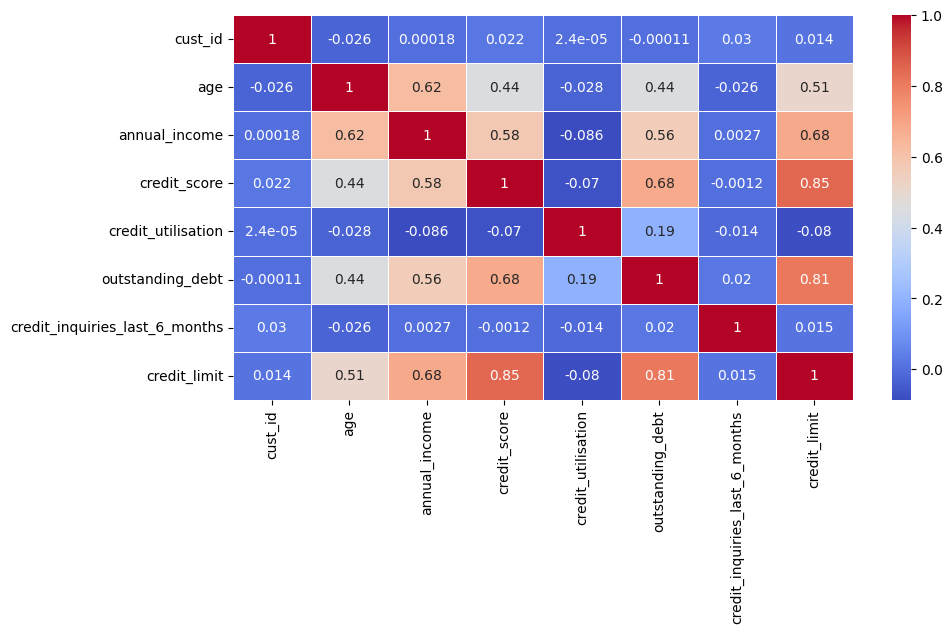

In [63]:
# find correlation amongst numeric columns
correlation_matrix = customer_info_df[num_cols].corr()

plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix,annot=True,linewidths=0.5,cmap='coolwarm')
plt.show()

In [64]:
transactions_df.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


Observations, 
1. We find that minimum transaction amount is set to **0.0** which is absurd and needs changing. 
2. We might also want to look at presence of outliers in **trans_amount** attribute to replace with suitable values.

In [65]:
transactions_df.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [66]:
transactions_df.shape

(500000, 7)

In [67]:
# check for null values
transactions_df.isna().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

To handle missing **Platform** values we look at for each customer with missing values the **platform they use the most to purchase from** and then replace it. 

In the event there exists any customer with a single entry having missing **Platform** value we replace the **most frequently used platform**.

In [68]:
# create a series that shows count of platforms used to purchase per customer
customerwise_platformfreq = transactions_df.groupby(['cust_id'])['platform'].agg(lambda x: x.mode().iloc[0])
customerwise_platformfreq

cust_id
1       Amazon
2       Amazon
3       Amazon
4       Amazon
5       Amazon
         ...  
996     Amazon
997     Amazon
998     Amazon
999     Amazon
1000    Amazon
Name: platform, Length: 1000, dtype: object

In [69]:
# replace missing platform values per customer at first with the most frequently used platform and if not then with global mode
transactions_df['platform'] = np.where(transactions_df['platform'].isna(),customerwise_platformfreq[transactions_df['cust_id']],transactions_df['platform'])

In [70]:
# do sanity check to see whether all nulls have been replaced
transactions_df.isna().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

In [71]:
# check entries with 0.0 as transaction value
zero_trans_df = transactions_df.loc[transactions_df['tran_amount']==0]
print(f'% of entries with zero transaction amount is: {(len(zero_trans_df)/len(transactions_df))*100}%')

% of entries with zero transaction amount is: 0.9468000000000001%


In [72]:
zero_trans_df.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
517,518,147,2023-01-01,0,Amazon,Electronics,Credit Card
533,534,891,2023-01-01,0,Amazon,Electronics,Credit Card
586,587,108,2023-01-01,0,Amazon,Electronics,Credit Card


As is seen there exists ~0.95% of records that show zero trnsaction amount. 

We replace such values with **Median** value for combination of **user, platform, product category & payment_type** resp. In case there still exists records with zero transaction amount we replace **Median** value corresponding to **user, platform and product_category** resp otherwise we perform substitution using **Median** value corresponding to **user and platform**.

In [73]:
trans_amt_for_each_usr_platform_prd_paymenttype = transactions_df.groupby(['cust_id','platform','product_category','payment_type'])['tran_amount'].transform("median")
trans_amt_for_each_usr_platform_prd_paymenttype

0           230.0
1            41.0
2           471.0
3            60.5
4            92.0
           ...   
499995       36.0
499996    53022.0
499997      224.0
499998      273.0
499999      295.0
Name: tran_amount, Length: 500000, dtype: float64

In [74]:
0.0 in trans_amt_for_each_usr_platform_prd_paymenttype.values

True

In [75]:
# replace zero transaction amount values basis customer, platform purchased from, product bought and payment type used.
transactions_df['tran_amount'] = np.where(transactions_df['tran_amount']==0,trans_amt_for_each_usr_platform_prd_paymenttype[transactions_df.index],transactions_df['tran_amount'])

In [76]:
# sanity check for absence of zero transaction amount. 
transactions_df.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3227.693021
std,144337.711635,288.641924,13098.169060
min,1.000000,1.000000,0.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,144.000000
75%,375000.250000,752.000000,401.000000
max,500000.000000,1000.000000,69999.000000


In [77]:
trans_amt_for_each_usr_platform_prd = transactions_df.groupby(['cust_id','platform','product_category'])['tran_amount'].transform("median")
trans_amt_for_each_usr_platform_prd

0         446.0
1          56.0
2         454.5
3          58.0
4          67.0
          ...  
499995     29.0
499996     66.0
499997    178.0
499998    260.0
499999    177.0
Name: tran_amount, Length: 500000, dtype: float64

In [78]:
# replace zero transaction amount values basis customer, platform purchased from and product bought.
transactions_df['tran_amount'] = np.where(transactions_df['tran_amount']==0,trans_amt_for_each_usr_platform_prd[transactions_df.index],transactions_df['tran_amount'])

In [79]:
# sanity check
transactions_df.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3228.545437
std,144337.711635,288.641924,13097.974381
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,145.000000
75%,375000.250000,752.000000,403.000000
max,500000.000000,1000.000000,69999.000000


Observations, 

Above data indicates that **no longer do we have zero transaction amount as the minimum value.**

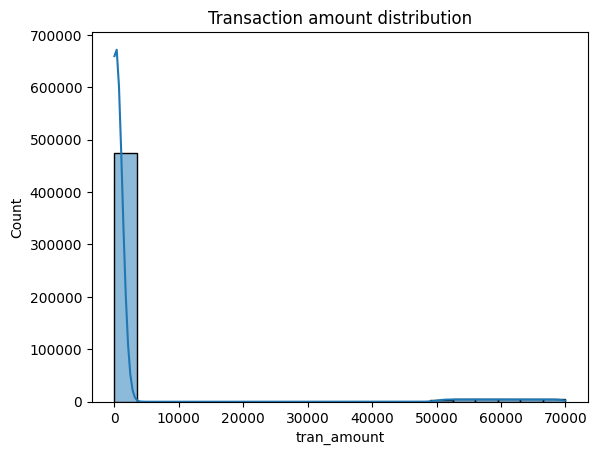

In [80]:
# plot transaction distribution
sns.histplot(data=transactions_df,x='tran_amount',bins=20,kde=True)
plt.title("Transaction amount distribution")
plt.show()

Observations, 
 
1. Above plot indicates that distribution is **right skewed** and hence to treat outliers present towards the right we use **IQR** or **business logic** as per availability.

In [81]:
# Obtain Q1 & Q3 using box and whisker plot
q1,q3 = transactions_df['tran_amount'].quantile([0.25,0.75])
IQR = q3-q1

# lower & upper set as per biz logic. In general we use 1.5*IQR but if biz requires we may become a bit flexible and use value>1.5 in this case 2.
lower = q1 - 2*IQR
upper = q3 + 2*IQR

lower,upper

(-608.0, 1077.0)

In [82]:
# get outliers in transaction amount
trans_amt_outliers = transactions_df.loc[transactions_df['tran_amount']>upper]

print(f'% of trans amt outliers is: {(len(trans_amt_outliers)/len(transactions_df))*100}%')

% of trans amt outliers is: 5.0%


To handle outliers we replace them with **Median** of **userwise product values**. 

In [83]:
transactions_df.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63.0,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99.0,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471.0,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33.0,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68.0,Amazon,Fashion & Apparel,Net Banking


In [84]:
userwise_prd_median = transactions_df.groupby(['cust_id','product_category'])['tran_amount'].transform("median")
userwise_prd_median

0         552.5
1          62.0
2         361.0
3          70.5
4          72.0
          ...  
499995     30.5
499996     59.0
499997    127.5
499998    300.0
499999    182.0
Name: tran_amount, Length: 500000, dtype: float64

In [85]:
transactions_df['tran_amount'] = np.where(transactions_df['tran_amount']>upper,userwise_prd_median[transactions_df.index],transactions_df['tran_amount'])

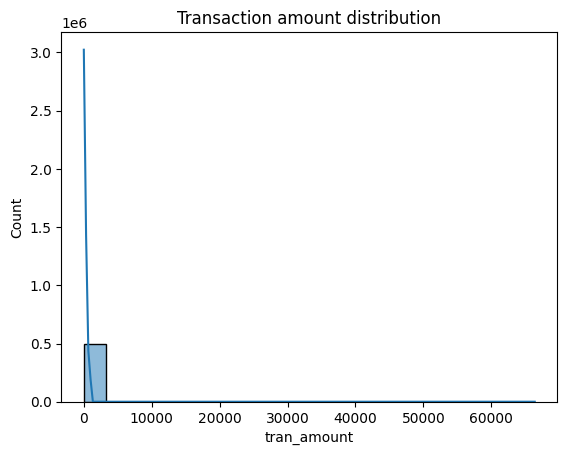

In [86]:
# sanity check for outlier removal
sns.histplot(transactions_df['tran_amount'],bins=20,kde=True)
plt.title("Transaction amount distribution")
plt.show()


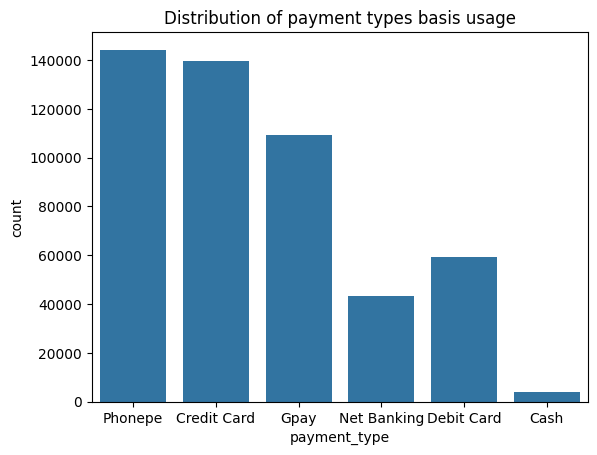

In [87]:
# plot distribution of payment types
sns.countplot(data=transactions_df,x='payment_type')
plt.title("Distribution of payment types basis usage")
plt.show()

In [88]:
customer_info_df.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_groups,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_risk_band
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,36-48,587,0.107928,1250.0,2.0,1250.0,550-649
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,300-549
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,300-549
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,36-48,708,0.586151,18090.0,2.0,40000.0,700-749


In [89]:
# merge customer info df with transactions df such that for each customer we get age-group and payment type(s) used.
total_customer_info_df = pd.merge(customer_info_df,transactions_df,on="cust_id",how="left")
total_customer_info_df.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_groups,credit_score,...,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_risk_band,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+,749,...,19571.0,0.0,40000.0,700-749,1283,2023-01-01,30.0,Shopify,Fashion & Apparel,Net Banking
1,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+,749,...,19571.0,0.0,40000.0,700-749,1382,2023-01-01,96.0,Amazon,Sports,Debit Card
2,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+,749,...,19571.0,0.0,40000.0,700-749,1521,2023-01-01,86.0,Meesho,Garden & Outdoor,Gpay
3,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+,749,...,19571.0,0.0,40000.0,700-749,1576,2023-01-01,149.0,Amazon,Beauty & Personal Care,Phonepe
4,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49+,749,...,19571.0,0.0,40000.0,700-749,1757,2023-01-01,37.0,Flipkart,Fashion & Apparel,Credit Card


In [90]:
agegroupwise_paymenttypes_usages = total_customer_info_df.groupby(['age_groups','payment_type'])['payment_type'].agg('count').unstack()
agegroupwise_paymenttypes_usages

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/276260607.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroupwise_paymenttypes_usages = total_customer_info_df.groupby(['age_groups','payment_type'])['payment_type'].agg('count').unstack()


payment_type,Cash,Credit Card,Debit Card,Gpay,Net Banking,Phonepe
age_groups,,,,,,
18-25,537,8706,20645,31899,5749,47594
26-35,1603,59877,17263,34719,16890,43075
36-48,1014,38034,10990,21934,10933,27415
49+,854,32656,9273,18558,9268,23051


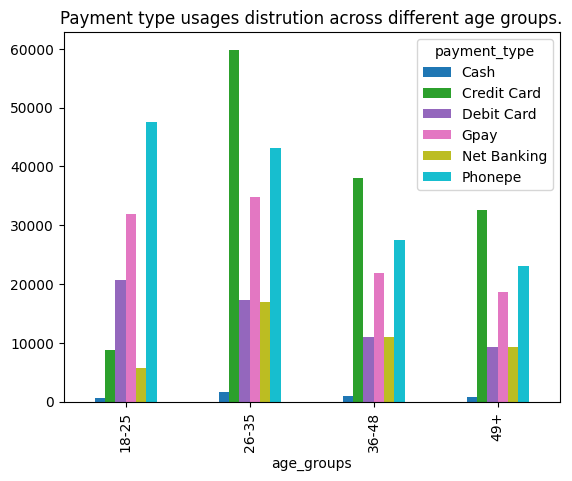

In [91]:
# setup a grouped bar-chart that displays agewise usages of different payment platforms
agegroupwise_paymenttypes_usages.plot(kind='bar',colormap='tab10')
plt.title("Payment type usages distrution across different age groups.")
plt.show()

In [93]:
agegroupwise_annualincome = total_customer_info_df.groupby(['age_groups'])['annual_income'].agg('median')
agegroupwise_annualincome

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/3667740069.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroupwise_annualincome = total_customer_info_df.groupby(['age_groups'])['annual_income'].agg('median')


age_groups
18-25     37472.0
26-35    133189.0
36-48    129681.0
49+      261191.5
Name: annual_income, dtype: float64

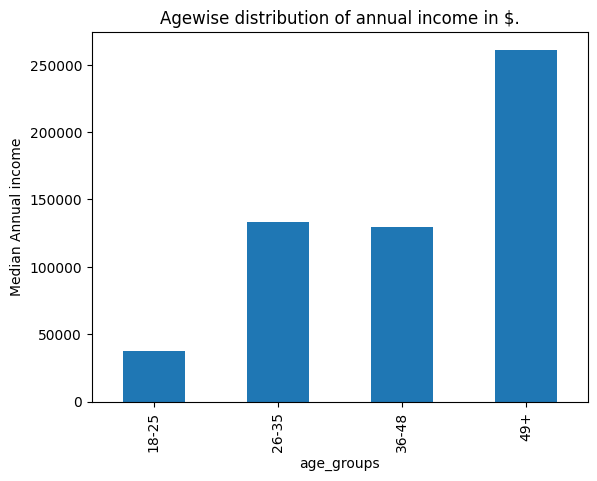

In [97]:
# plot distribution of annual income by age-groups
agegroupwise_annualincome.plot(kind='bar',colormap='tab10')
plt.ylabel('Median Annual income')
plt.title("Agewise distribution of annual income in $.")
plt.show()

In [98]:
agegroupwise_occupation = total_customer_info_df.groupby(['age_groups','occupation'])['occupation'].agg('count').unstack()
agegroupwise_occupation

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/2921909480.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroupwise_occupation = total_customer_info_df.groupby(['age_groups','occupation'])['occupation'].agg('count').unstack()


occupation,Accountant,Artist,Business Owner,Consultant,Data Scientist,Freelancer,Fullstack Developer
age_groups,,,,,,,
18-25,507,7641,0,0,5950,68424,32608
26-35,5490,11593,15375,0,61849,38128,40992
36-48,1986,0,45769,38377,24188,0,0
49+,0,0,83776,9884,0,0,0


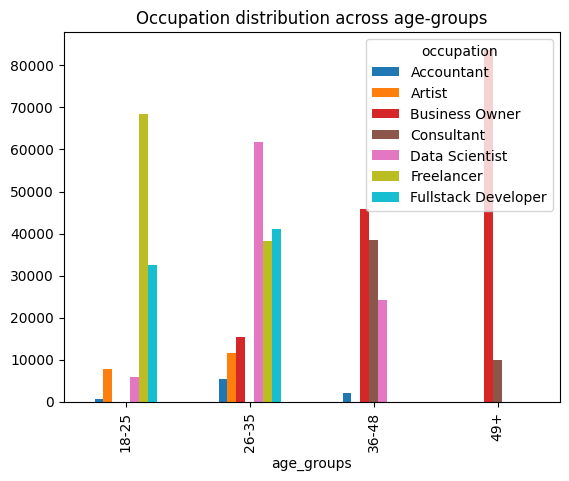

In [99]:
# plot occupation distribution across different age-groups
agegroupwise_occupation.plot(kind='bar',colormap='tab10')
plt.title("Occupation distribution across age-groups")
plt.show()

In [100]:
agegroupwise_location = total_customer_info_df.groupby(['age_groups','location'])['location'].agg('count').unstack()
agegroupwise_location

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/3569475951.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroupwise_location = total_customer_info_df.groupby(['age_groups','location'])['location'].agg('count').unstack()


location,City,Rural,Suburb
age_groups,,,
18-25,81510,12397,21223
26-35,125965,13765,33697
36-48,70210,9034,31076
49+,59597,6677,27386


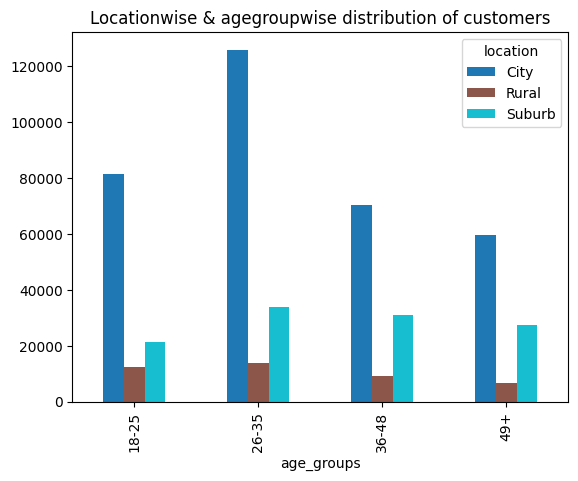

In [101]:
# plot distribution of customers age-groupwise as per location they reside in.
agegroupwise_location.plot(kind='bar',colormap='tab10')
plt.title("Locationwise & agegroupwise distribution of customers")
plt.show()

In [102]:
agegroupwise_platform_usage = total_customer_info_df.groupby(['age_groups','platform'])['platform'].agg('count').unstack()
agegroupwise_platform_usage

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/4251723842.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroupwise_platform_usage = total_customer_info_df.groupby(['age_groups','platform'])['platform'].agg('count').unstack()


platform,Alibaba,Amazon,Cred,Ebay,Flipkart,Meesho,Shopify
age_groups,,,,,,,
18-25,16983,36018,5711,2336,28057,16903,9122
26-35,25305,54120,8608,3484,42826,25341,13743
36-48,16422,34445,5408,2138,27132,16111,8664
49+,13779,29306,4666,1845,22921,13835,7308


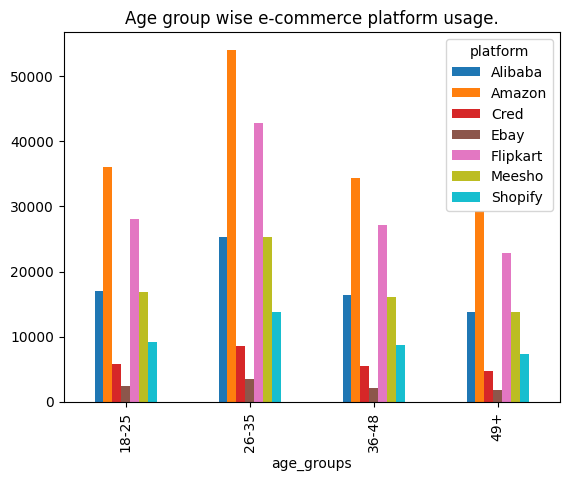

In [103]:
# plot e-commerce platform engagement across diff age groups
agegroupwise_platform_usage.plot(kind='bar',colormap='tab10')
plt.title("Age group wise e-commerce platform usage.")
plt.show()

In [104]:
agegroupwise_product_category = total_customer_info_df.groupby(['age_groups','product_category'])['product_category'].agg('count').unstack()
agegroupwise_product_category

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/1327423422.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroupwise_product_category = total_customer_info_df.groupby(['age_groups','product_category'])['product_category'].agg('count').unstack()


product_category,Beauty & Personal Care,Books,Electronics,Fashion & Apparel,Garden & Outdoor,Home Decor,Kitchen Appliances,Sports,Toys & Games
age_groups,,,,,,,,,
18-25,17079,5738,35298,39725,1155,1117,1196,11535,2287
26-35,17394,3490,44856,34223,10360,16933,25609,17095,3467
36-48,11035,2216,28161,21977,6542,10930,16468,10913,2078
49+,9480,1854,23917,18317,5513,9296,14009,9436,1838


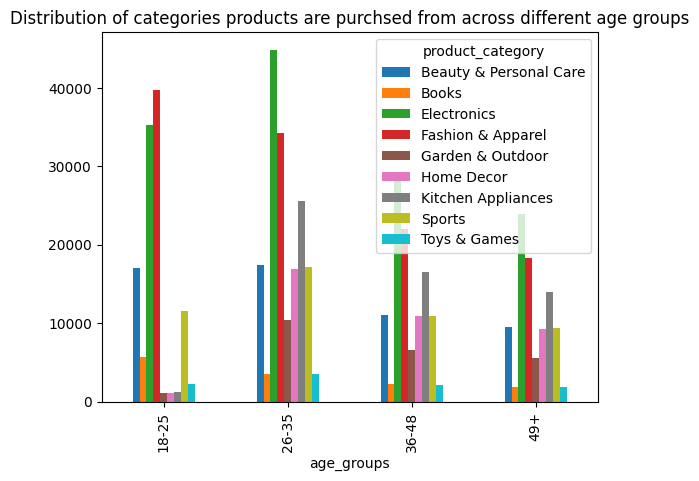

In [105]:
# plot distribution of product category purchased from e-commerce sites across age-groups
agegroupwise_product_category.plot(kind='bar',colormap='tab10')
plt.title("Distribution of categories products are purchsed from across different age groups")
plt.show()

In [106]:
agegroupwise_credit_limit = total_customer_info_df.groupby(['age_groups','credit_limit'])['credit_limit'].agg('count').unstack()
agegroupwise_credit_limit

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_17493/4109348122.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroupwise_credit_limit = total_customer_info_df.groupby(['age_groups','credit_limit'])['credit_limit'].agg('count').unstack()


credit_limit,500.0,750.0,1000.0,1250.0,1500.0,20000.0,40000.0,60000.0
age_groups,,,,,,,,
18-25,50881,12239,14536,15437,21526,0,0,511
26-35,41760,16501,13936,12006,19434,13027,25121,31642
36-48,22520,7128,11519,6037,7054,7950,25024,23088
49+,7987,1963,3919,2630,3965,493,23881,48822


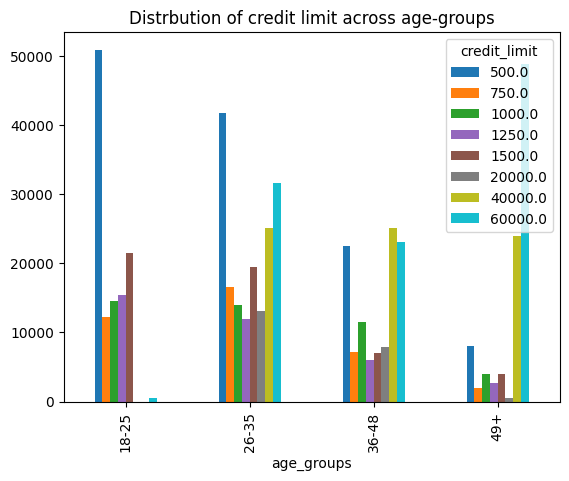

In [107]:
# plot distribution of credit limit across several age groups
agegroupwise_credit_limit.plot(kind='bar',colormap='tab10')
plt.title("Distrbution of credit limit across age-groups")
plt.show()

#### TARGET GROUP FINDING
From above **EDA** we come up with following findings that help us determine the right **target group** for **Atliqo Bank's** credit card. 

1. From the grouped bar chart above we see that people that fall within the age-group **26-35 yrs** show maximum credit card usage followed by those within **36-48 yrs** with the minimuum being **18-25 yrs**. This could primarily be due to that teenager's are mostly students who get paid by their parent's while those older are either professionals or retired personnel with a decent enough corpus and hence can use **credit cards**.

**Atliqo Bank** may come up with a **cerdit card** that targets **18-25 yrs** group offering benefits for students.

To target the groups that already use credit cards it may be challenging for they may not want to use any new **credit cards** than what they already have unless **Atliqo's credit card** has something out of the box benefit to offer along with cost effectiveness in comparison to the cards of bank's people are already in use of. 

The **Target Group** decided is **18-25 yrs**.